## Week6 Lab Convolution network
## Part 1: Lab Setup
1.1 Install Required Libraries

In [1]:
!pip install tensorflow matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 18.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 22.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 25.0 MB/s eta 0:00:00a 0:00:01


## 1.2 Import Packages

In [3]:
import os


# Prevent WSL memory allocation crashes
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs Available: {tf.config.list_physical_devices('GPU')}")

# Test if it can do math on the GPU!
with tf.device('/GPU:0'):
    test = tf.constant([1, 2, 3])
    result = test * 2
    print(f"GPU Math Test Result: {result.numpy()}")

TensorFlow version: 2.17.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Math Test Result: [2 4 6]


I0000 00:00:1787015188.641207     163 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787015189.115830     163 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787015189.115894     163 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787015189.119126     163 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1787015189.119176     163 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

## Part 2: Load and Explore Dataset

In [4]:
import os
import tensorflow as tf
import numpy as np
import shutil

def force_reload_mnist():
    """Force re-download of MNIST dataset"""
    
    # Step 1: Clear cache directories
    keras_cache = os.path.expanduser('~/.keras/datasets')
    if os.path.exists(keras_cache):
        print(f"📁 Removing cache directory: {keras_cache}")
        shutil.rmtree(keras_cache)
        print("✅ Cache cleared!")
    
    # Also try to clear any temporary files
    temp_cache = os.path.expanduser('~/.keras/datasets/mnist.npz')
    if os.path.exists(temp_cache):
        os.remove(temp_cache)
        print("✅ Temporary file removed!")
    
    # Step 2: Re-download with progress
    print("\n🔄 Downloading MNIST dataset fresh...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    
    # Step 3: Verify dataset integrity
    print("\n✅ Download complete!")
    print(f"Training set: {x_train.shape[0]} samples, shape: {x_train[0].shape}")
    print(f"Testing set: {x_test.shape[0]} samples, shape: {x_test[0].shape}")
    print(f"Label range: {y_train.min()} to {y_train.max()}")
    
    # Step 4: Normalize
    x_train = x_train / 255.0
    x_test = x_test / 255.0
    
    # Step 5: Reshape for CNN
    x_train = x_train[..., np.newaxis]
    x_test = x_test[..., np.newaxis]
    
    return (x_train, y_train), (x_test, y_test)

# Run the function
(x_train, y_train), (x_test, y_test) = force_reload_mnist()

print(f"\nFinal shapes:")
print(f"x_train: {x_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


🔄 Downloading MNIST dataset fresh...
11490434/11490434 [==============================] - 2s 0us/step

✅ Download complete!
Training set: 60000 samples, shape: (28, 28)
Testing set: 10000 samples, shape: (28, 28)
Label range: 0 to 9

Final shapes:
x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)
y_train: (60000,)
y_test: (10000,)


## Show Sample Images

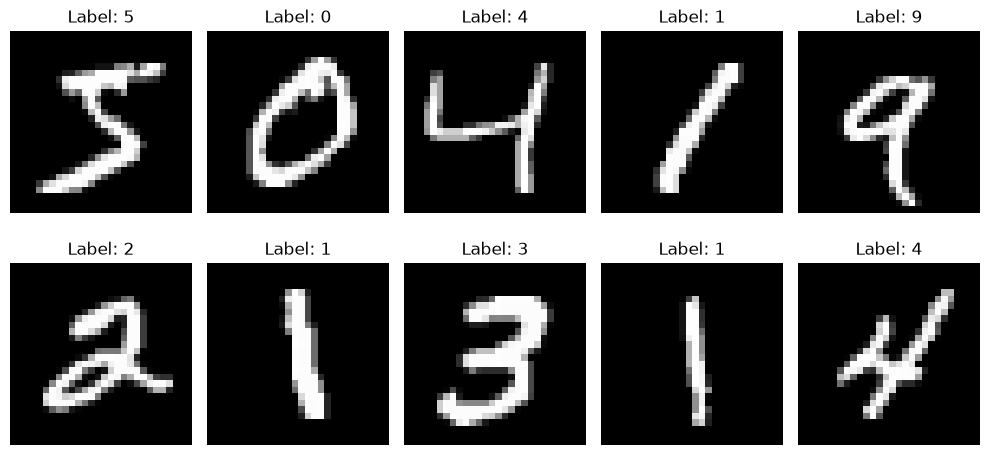

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 3: Build CNN Model
### 3.1 Simple CNN Architecture

In [6]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1),
        name="conv2d_1"
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        name="conv2d_2"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Tue Aug 18 01:06:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.57.01              KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   52C    P8              4W /   80W |     113MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3.2 Compile Model

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Part 4: Train the Model

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    validation_data=(x_test, y_test),
    batch_size=128
)

Epoch 1/100
469/469 [==============================] - ETA: 0s - loss: 0.0419 - accuracy: 0.9867 

W0000 00:00:1787015387.298072     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.298362     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.298564     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.298762     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.299010     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.299249     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.299470     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.299660     267 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.299899     267 gp

469/469 [==============================] - 3s 7ms/step - loss: 0.0419 - accuracy: 0.9867 - val_loss: 0.0268 - val_accuracy: 0.9913
Epoch 2/100
 31/469 [>.............................] - ETA: 2s - loss: 0.0453 - accuracy: 0.9856

W0000 00:00:1787015387.661385     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.661593     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.661740     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.661842     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.662012     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.662114     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.662307     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.662622     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015387.662785     265 gp

464/469 [============================>.] - ETA: 0s - loss: 0.0382 - accuracy: 0.9876

...

469/469 [==============================] - 3s 6ms/step - loss: 0.0159 - accuracy: 0.9947 - val_loss: 0.0200 - val_accuracy: 0.9943
Epoch 18/100
467/469 [============================>.] - ETA: 0s - loss: 0.0146 - accuracy: 0.9950

W0000 00:00:1787015436.312607     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.312888     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.313088     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.313272     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.313511     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.313718     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.313918     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.314108     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015436.314297     265 gp

469/469 [==============================] - 3s 6ms/step - loss: 0.0146 - accuracy: 0.9950 - val_loss: 0.0243 - val_accuracy: 0.9920
Epoch 19/100
469/469 [==============================] - ETA: 0s - loss: 0.0148 - accuracy: 0.9949

W0000 00:00:1787015438.868299     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.868649     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.868864     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.869339     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.869579     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.869967     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.870210     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.870456     265 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787015438.870656     265 gp

469/469 [==============================] - 3s 5ms/step - loss: 0.0148 - accuracy: 0.9949 - val_loss: 0.0225 - val_accuracy: 0.9941
Epoch 20/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0129 - accuracy: 0.9954 - val_loss: 0.0233 - val_accuracy: 0.9930
Epoch 21/100
469/469 [==============================] - 3s 5ms/step - loss: 0.0125 - accuracy: 0.9959 - val_loss: 0.0246 - val_accuracy: 0.9928
Epoch 22/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0120 - accuracy: 0.9958 - val_loss: 0.0229 - val_accuracy: 0.9941
Epoch 23/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0130 - accuracy: 0.9955 - val_loss: 0.0238 - val_accuracy: 0.9936
Epoch 24/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0124 - accuracy: 0.9957 - val_loss: 0.0268 - val_accuracy: 0.9935
Epoch 25/100
469/469 [==============================] - 3s 6ms/step - loss: 0.0106 - accuracy: 0.9962 - val_loss: 0.0252 - val_accuracy: 0.9928
Epoch

## Part 5: Evaluate Model

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

313/313 - 1s - loss: 0.0328 - accuracy: 0.9940 - 993ms/epoch - 3ms/step
Test Loss: 0.0328
Test Accuracy: 99.40%


## Plot Learning Curves

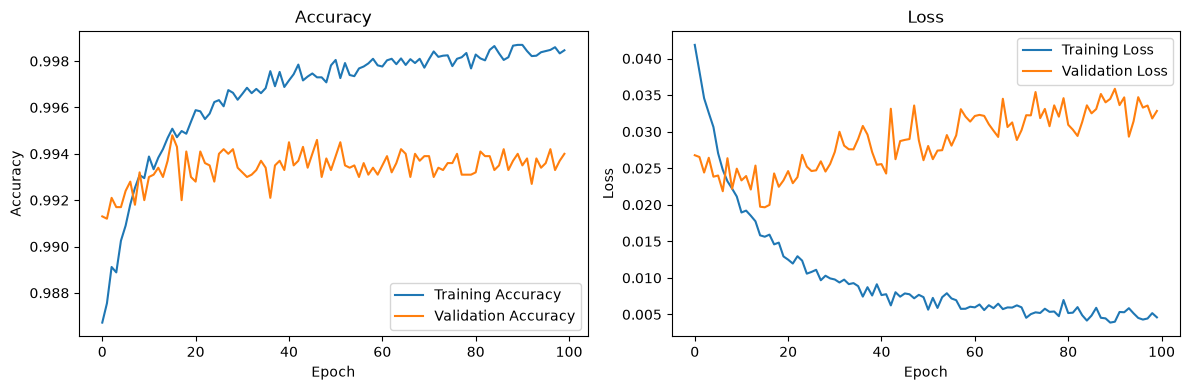

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Confusion Matrix

313/313 [==============================] - 1s 2ms/step


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

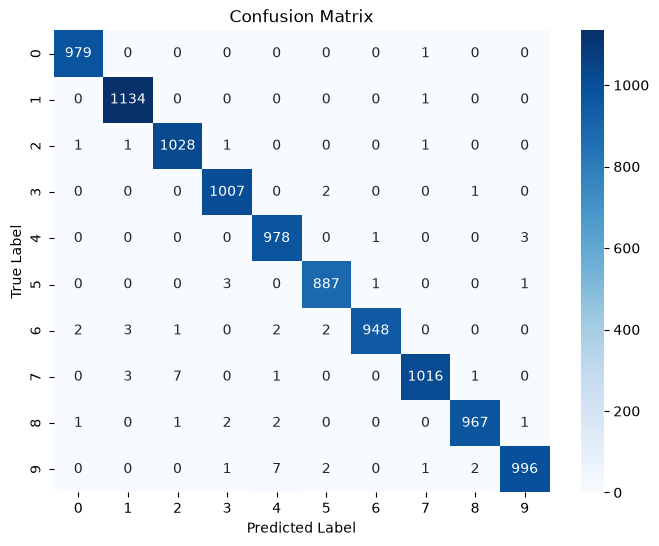

In [13]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = tf.math.confusion_matrix(y_test, y_pred).numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Part 6: Visualize Filters

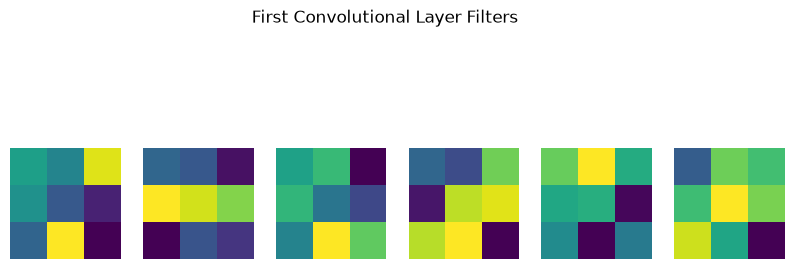

In [14]:
# Extract weights of the first Conv2D layer
filters, biases = model.get_layer("conv2d_1").get_weights()

# Normalize filter values for visualization
filters = filters - filters.min()
filters = filters / filters.max()

plt.figure(figsize=(10, 4))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap="viridis")
    plt.axis("off")

plt.suptitle("First Convolutional Layer Filters")
plt.show()

## Part 7: Visualize Grad-CAM
7.1 Define Grad-CAM Function

In [15]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    denominator = tf.math.reduce_max(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (denominator + 1e-8)

    return heatmap.numpy()

## 7.2 Apply Grad-CAM

W0000 00:00:1787016057.064453     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.074246     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.075264     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.075825     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.076375     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.076612     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.076759     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.076906     163 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016057.077062     163 gp

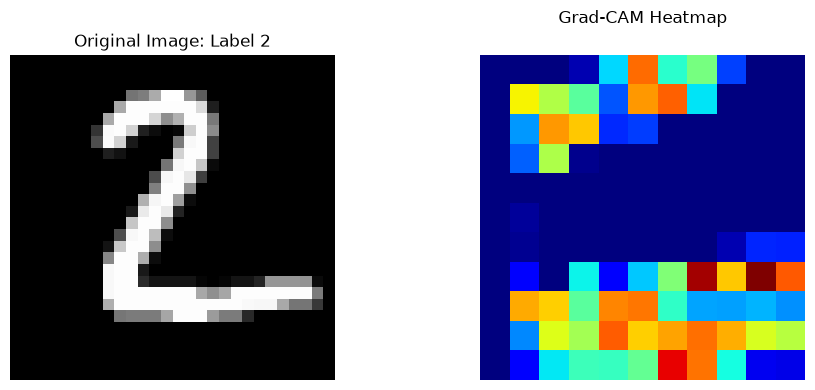

In [16]:
img_index = 1
img = x_test[img_index][np.newaxis, ...]

heatmap = make_gradcam_heatmap(
    img_array=img,
    model=model,
    last_conv_layer_name="conv2d_2"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_test[img_index].squeeze(), cmap="gray")
plt.title(f"Original Image: Label {y_test[img_index]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.matshow(heatmap, fignum=False, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.tight_layout()
plt.show()

## Part 8: Prediction Inspection
Inspect several predictions visually to identify correct and incorrect classifications.

1/1 [==============================] - 0s 31ms/step


W0000 00:00:1787016145.767330     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.767711     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768018     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768145     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768259     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768368     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768628     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768854     270 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1787016145.768988     270 gp

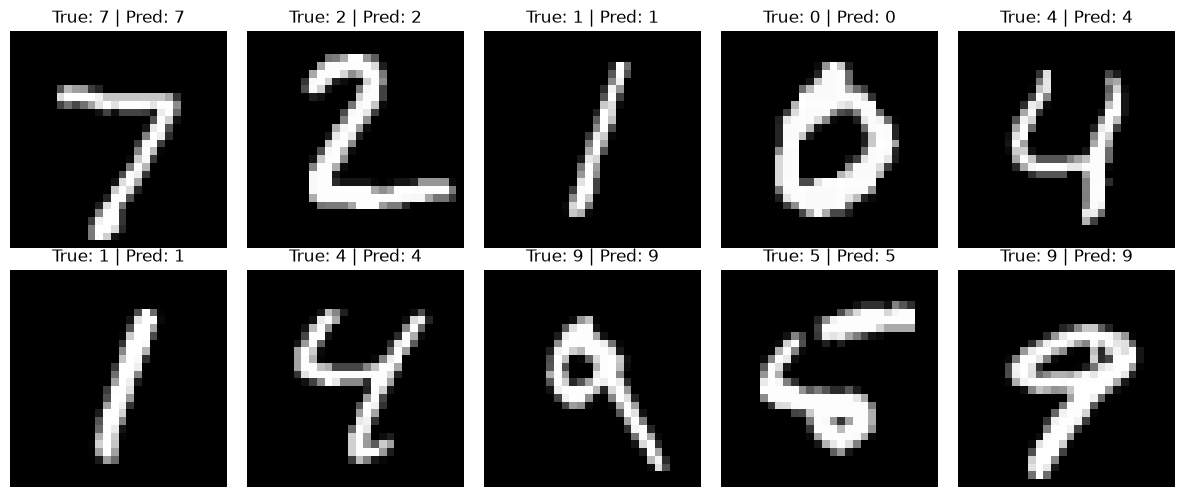

In [17]:
sample_indices = np.arange(10)
sample_images = x_test[sample_indices]
sample_labels = y_test[sample_indices]

sample_probs = model.predict(sample_images)
sample_preds = np.argmax(sample_probs, axis=1)

plt.figure(figsize=(12, 5))

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {sample_labels[i]} | Pred: {sample_preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 9: Optional Experiments

In [18]:
# Example experiment ideas:
# 1. Change activation='relu' to activation='tanh'
# 2. Change optimizer='adam' to optimizer='sgd' or optimizer='rmsprop'
# 3. Add BatchNormalization after Conv2D layers
# 4. Change Dropout from 0.5 to 0.25
# 5. Increase epochs from 5 to 10
# 6. Add EarlyStopping callback

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
## Part 10: Save the Mode

In [19]:
model.save("lecture6_lab2_cnn_mnist_model.keras")

print("Model saved as lecture6_lab2_cnn_mnist_model.keras")

Model saved as lecture6_lab2_cnn_mnist_model.keras
